# 신용카드 채무불이행 고객 예측

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset


## 모델링 프로세스 요약

**Target** : `default` (0 = 정상, 1 = 채무불이행)

| 단계 | 내용 |
|------|------|
| 1단계 EDA | 클래스 비율 · 결측치 · 이상치 · 피처 분포 · 상관관계 |
| 2단계 전처리 | 이상값 통합 · One-Hot Encoding · StandardScaler |
| 3단계 Split | train_test_split (stratify, 80:20) |
| 4단계 모델 학습 | 베이스라인 → class_weight → SMOTE 단계별 비교 |
| 5단계 평가 | Accuracy / Precision / Recall / F1 / ROC-AUC |
| 6단계 피처 중요도 | 트리 기반 feature importance 시각화 |


In [ ]:
# pip install xlrd imbalanced-learn xgboost --break-system-packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows: Malgun Gothic / Mac: AppleGothic / Linux: NanumGothic) ──
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [2]:
import urllib.request, os

os.makedirs('./data', exist_ok=True)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
df.to_csv('./data/UCI_Credit_Card.csv', index=False)

card_df = df.drop('ID', axis=1)
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target   = card_df['default']
X_features = card_df.drop('default', axis=1)

print(f'데이터 shape : {card_df.shape}')
card_df.head(3)


데이터 shape : (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


# 1. EDA


=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)      : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


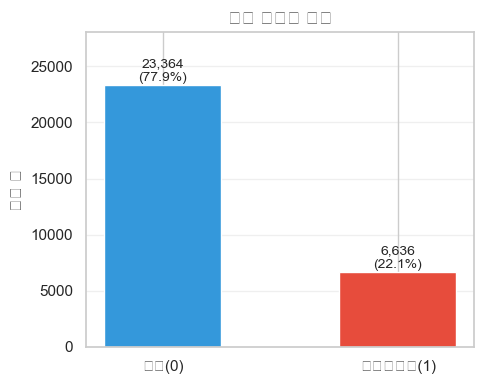

In [3]:
# 1-1. 타깃 클래스 비율 확인
print('=== 타깃 클래스 분포 ===')
print(y_target.value_counts())
print()
print(f'정상(0)      : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})')
print(f'채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})')

fig, ax = plt.subplots(figsize=(5, 4))
counts = y_target.value_counts().sort_index()
bars = ax.bar(['정상(0)', '채무불이행(1)'], counts.values,
              color=['#3498DB', '#E74C3C'], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}\n({v/len(y_target):.1%})', ha='center', va='bottom', fontsize=10)
ax.set_title('타깃 클래스 분포', fontsize=13, fontweight='bold')
ax.set_ylabel('샘플 수')
ax.set_ylim(0, counts.max() * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**분석 결과**
- 정상(0) : 23,364명 (77.9%) / 채무불이행(1) : 6,636명 (22.1%)
- 비율 약 **4:1 → 클래스 불균형(Class Imbalance) 존재**
- Accuracy만으로 평가 불충분 → 모델이 전부 0 예측 시에도 77.9% 달성 가능
- **Recall, F1-Score, ROC-AUC** 를 주요 평가 지표로 사용
- 채무불이행 탐지 실패 = 비즈니스 손실 → **Recall** 특히 중요


In [4]:
# 1-2. 결측치 탐색
missing_cnt   = card_df.isnull().sum()
missing_ratio = (missing_cnt / len(card_df) * 100).round(2)

missing_df = (
    pd.DataFrame({'missing_count': missing_cnt, 'missing_ratio(%)': missing_ratio})
    .query('missing_count > 0')
    .sort_values('missing_ratio(%)', ascending=False)
)

if missing_df.empty:
    print('결측치 없음 → 별도 처리 불필요 ✓')
else:
    display(missing_df)


결측치 없음 → 별도 처리 불필요 ✓


,feature,outlier_count,outlier_ratio(%),lower_bound,upper_bound
6,PAY_2,4410,14.70,-2.500,1.500
7,PAY_3,4209,14.03,-2.500,1.500
8,PAY_4,3508,11.69,-2.500,1.500
5,PAY_0,3130,10.43,-2.500,1.500
10,PAY_6,3079,10.26,-2.500,1.500
20,PAY_AMT4,2994,9.98,-5279.875,9589.125
9,PAY_5,2968,9.89,-2.500,1.500
22,PAY_AMT6,2958,9.86,-5705.625,9823.375
21,PAY_AMT5,2945,9.82,-5416.000,9700.000
17,PAY_AMT1,2745,9.15,-5009.000,11015.000


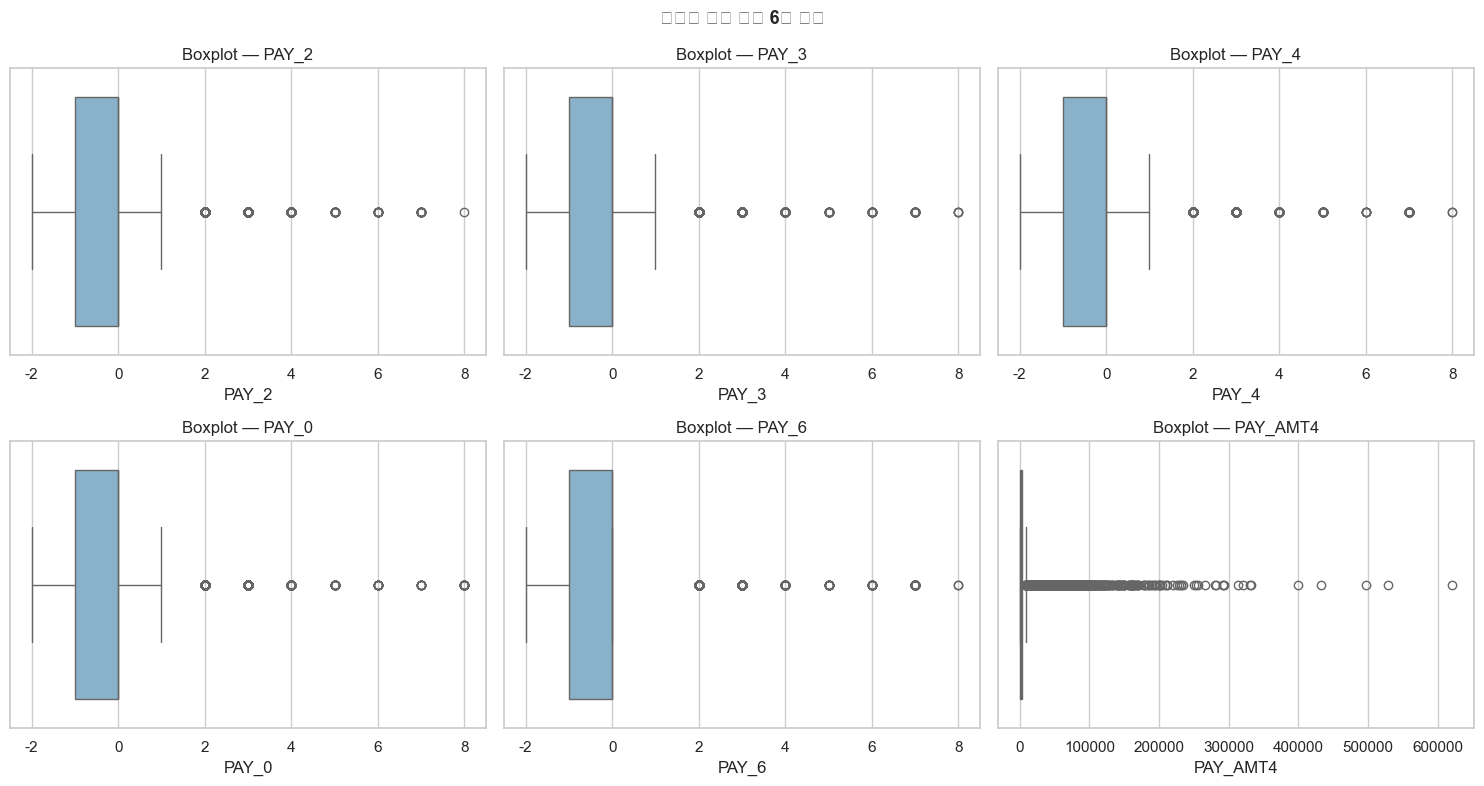

In [5]:
# 1-3. 이상치 탐색 (IQR 기준) — X_features 기준으로만 탐색 (타깃 제외)
outlier_summary = []

for col in X_features.select_dtypes(include=[np.number]).columns:
    q1    = X_features[col].quantile(0.25)
    q3    = X_features[col].quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask  = (X_features[col] < lower) | (X_features[col] > upper)
    outlier_summary.append([col, int(mask.sum()), round(mask.mean()*100, 2), lower, upper])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['feature', 'outlier_count', 'outlier_ratio(%)', 'lower_bound', 'upper_bound']
).sort_values('outlier_ratio(%)', ascending=False)

display(outlier_df.head(15))

# 이상치 비율 상위 6개 박스플롯
top6 = outlier_df.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), top6):
    sns.boxplot(x=X_features[col], ax=ax, color='#7FB3D5')
    ax.set_title(f'Boxplot — {col}')
plt.suptitle('이상치 비율 상위 6개 피처', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**이상치 분석 결과**
- `PAY_*` : IQR 기준 이상치로 분류되나 -2(소비없음), -1(정상납부), 0(리볼빙), 1~8(연체월수)로 **실제 정상 값** → 제거 불필요
- `PAY_AMT*` : 극단적 고액 납부 존재 → 실제 납부 데이터로 허용
- `BILL_AMT*` : 음수값(과납 크레딧) 존재 → 이상치 아님
- **전처리 필요** : `EDUCATION`(0,5,6), `MARRIAGE`(0) → 미정의 이상값 → 4/3으로 통합


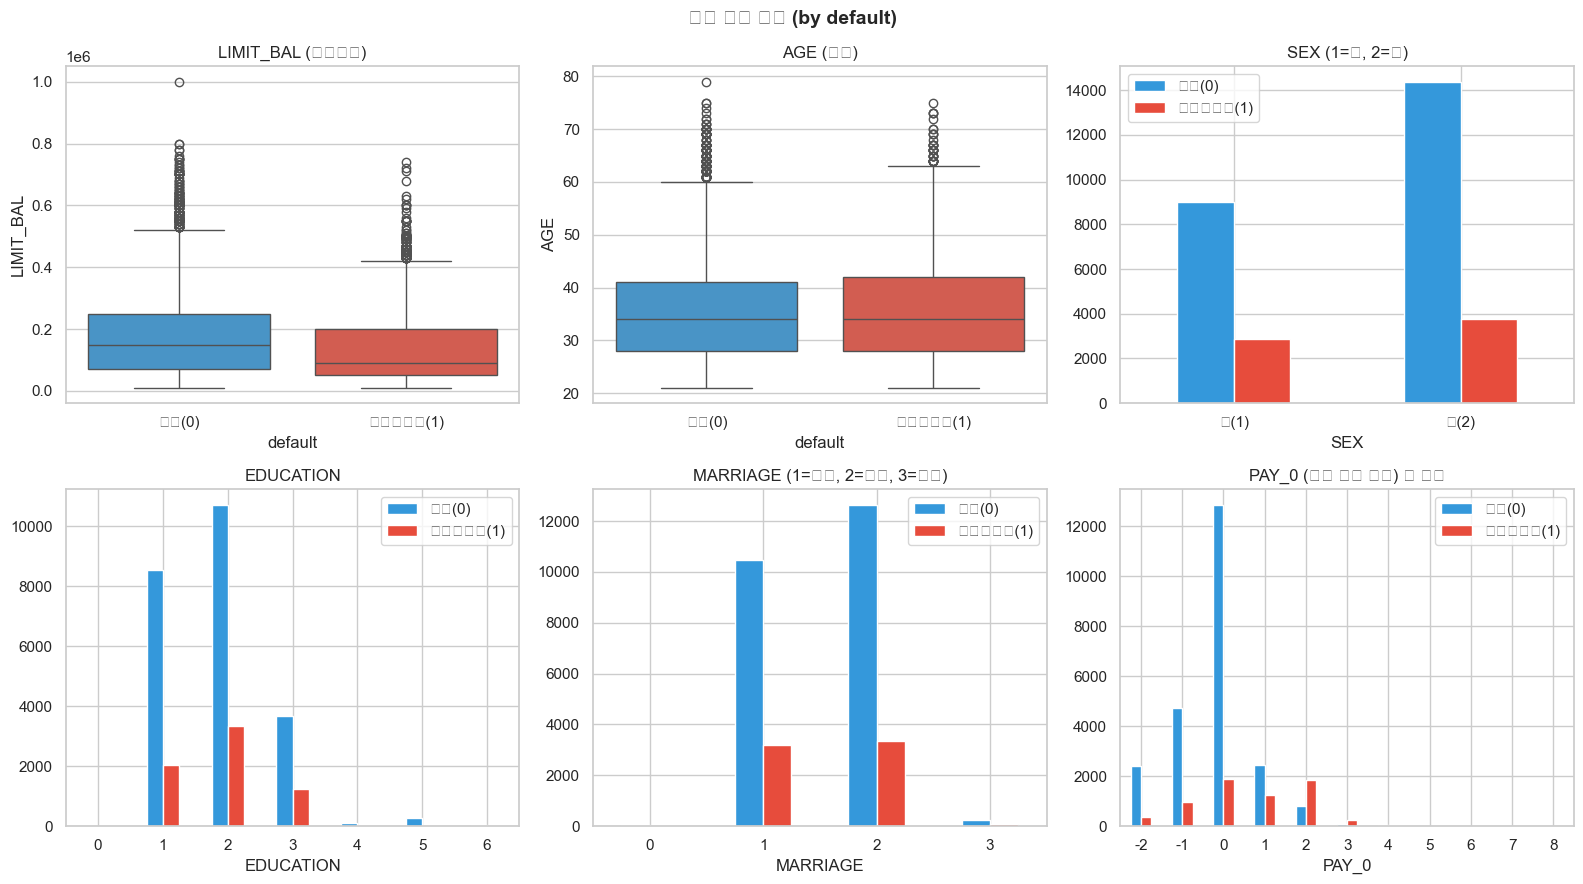

In [6]:
# 1-4. 주요 범주형 피처 분포 (타깃 기준)
palette = ['#3498DB', '#E74C3C']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('주요 피처 분포 (by default)', fontsize=14, fontweight='bold')

# LIMIT_BAL
sns.boxplot(x='default', y='LIMIT_BAL', data=card_df, hue='default',
            palette=palette, legend=False, ax=axes[0,0])
axes[0,0].set_title('LIMIT_BAL (신용한도)')
axes[0,0].set_xticklabels(['정상(0)', '채무불이행(1)'])

# AGE
sns.boxplot(x='default', y='AGE', data=card_df, hue='default',
            palette=palette, legend=False, ax=axes[0,1])
axes[0,1].set_title('AGE (나이)')
axes[0,1].set_xticklabels(['정상(0)', '채무불이행(1)'])

# SEX
sex_ratio = card_df.groupby(['SEX','default']).size().unstack(fill_value=0)
sex_ratio.plot(kind='bar', ax=axes[0,2], color=palette, edgecolor='white', legend=True)
axes[0,2].set_title('SEX (1=남, 2=여)')
axes[0,2].set_xticklabels(['남(1)', '여(2)'], rotation=0)
axes[0,2].legend(['정상(0)', '채무불이행(1)'])

# EDUCATION
edu_ratio = card_df.groupby(['EDUCATION','default']).size().unstack(fill_value=0)
edu_ratio.plot(kind='bar', ax=axes[1,0], color=palette, edgecolor='white', legend=True)
axes[1,0].set_title('EDUCATION')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=0)
axes[1,0].legend(['정상(0)', '채무불이행(1)'])

# MARRIAGE
mar_ratio = card_df.groupby(['MARRIAGE','default']).size().unstack(fill_value=0)
mar_ratio.plot(kind='bar', ax=axes[1,1], color=palette, edgecolor='white', legend=True)
axes[1,1].set_title('MARRIAGE (1=기혼, 2=미혼, 3=기타)')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
axes[1,1].legend(['정상(0)', '채무불이행(1)'])

# PAY_0
pay_ratio = card_df.groupby(['PAY_0','default']).size().unstack(fill_value=0)
pay_ratio.plot(kind='bar', ax=axes[1,2], color=palette, edgecolor='white', legend=True)
axes[1,2].set_title('PAY_0 (최근 납부 상태) ★ 핵심')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=0)
axes[1,2].legend(['정상(0)', '채무불이행(1)'])

plt.tight_layout()
plt.show()


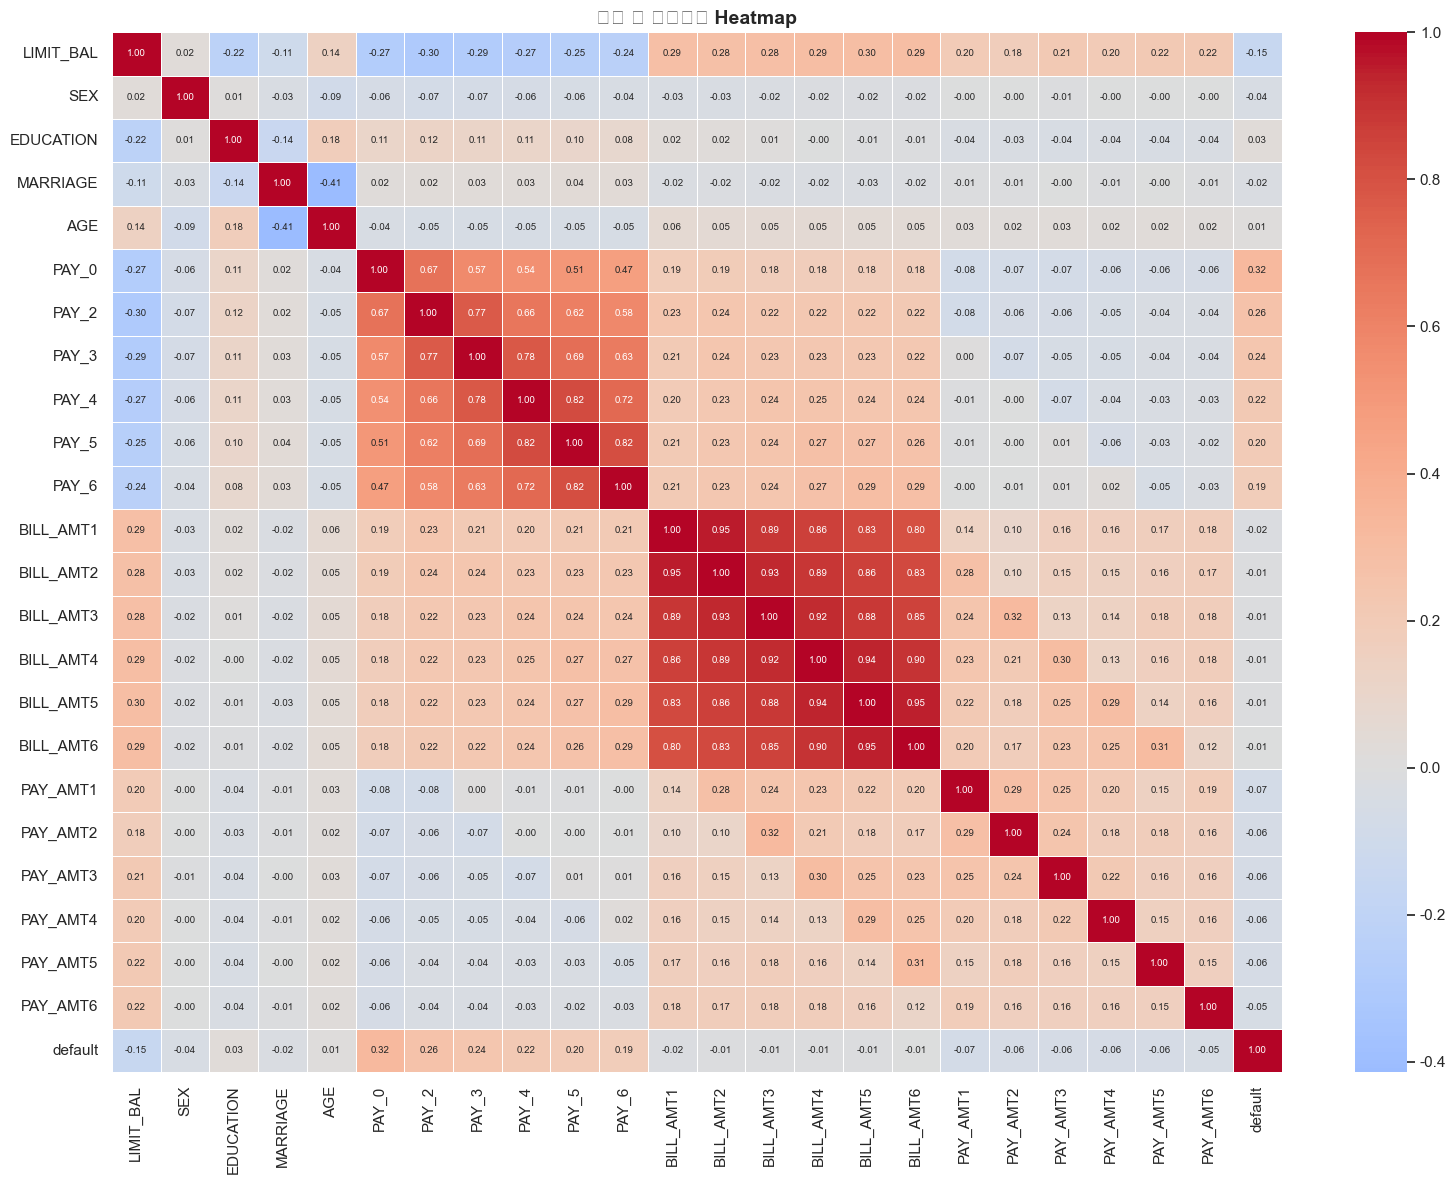

=== default 와의 상관관계 (절대값 내림차순) ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.028006
MARRIAGE     0.024339
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076
AGE          0.013890
BILL_AMT4    0.010156
BILL_AMT5    0.006760
BILL_AMT6    0.005372


In [7]:
# 1-5. 피처 간 상관관계 히트맵 + 타깃과의 상관 순위
corr = card_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('피처 간 상관관계 Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== default 와의 상관관계 (절대값 내림차순) ===')
corr_target = corr['default'].drop('default').abs().sort_values(ascending=False)
print(corr_target.to_string())


**상관관계 분석 결과**

| 피처 | |default| 상관계수 | 해석 |
|------|-----------|----------|
| `PAY_0` | 0.32 | **핵심 예측 피처** — 연체월수가 높을수록 채무불이행 급증 |
| `PAY_2~6` | 0.19~0.26 | 연체 상태 피처군 전반적으로 유효 |
| `LIMIT_BAL` | 0.15 | 신용한도 높을수록 채무불이행 낮음 |
| `BILL_AMT1~6` | 0.01~0.02 | 상관관계 거의 없음 |
| `SEX`, `AGE`, `EDUCATION`, `MARRIAGE` | 0.01~0.04 | 예측 기여도 낮음 |

**다중공선성 주의**
- `BILL_AMT1~6` 간 상관계수 0.80~0.95 → 다중공선성 높음
- `PAY_0~6` 간 상관계수 0.47~0.82 → 높음

# 2. 데이터 전처리

| 항목 | 대상 컬럼 | 처리 방법 |
|------|-----------|----------|
| 불필요 컬럼 제거 | `ID` | 로드 시 제거 완료 ✓ |
| 이상값 통합 | `EDUCATION`(0,5,6→4), `MARRIAGE`(0→3) | replace |
| 범주형 인코딩 | `SEX`, `EDUCATION`, `MARRIAGE` | SEX: 이진변환 / 나머지: One-Hot |
| 수치형 스케일링 | `LIMIT_BAL`, `AGE`, `PAY_*`, `BILL_AMT*`, `PAY_AMT*` | StandardScaler |

In [21]:
# 2-1. 범주형 피처 인코딩
from sklearn.preprocessing import StandardScaler

X_enc = X_features.copy()

# (A) SEX: 1=male, 2=female → 0/1 이진 변환
X_enc['SEX'] = X_enc['SEX'].map({1: 0, 2: 1})

# (B) EDUCATION 이상값 통합: 0·5·6 → 4(others)
X_enc['EDUCATION'] = X_enc['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
print('EDUCATION 분포 (정리 후):')
print(X_enc['EDUCATION'].value_counts().sort_index())
print()

# (C) MARRIAGE 이상값 통합: 0 → 3(others)
X_enc['MARRIAGE'] = X_enc['MARRIAGE'].replace({0: 3})
print('MARRIAGE 분포 (정리 후):')
print(X_enc['MARRIAGE'].value_counts().sort_index())
print()

# (D) EDUCATION · MARRIAGE One-Hot Encoding
X_enc = pd.get_dummies(X_enc, columns=['EDUCATION', 'MARRIAGE'], drop_first=False, dtype=int)

print(f'인코딩 후 shape: {X_enc.shape}')
dummy_cols = [c for c in X_enc.columns if 'EDUCATION_' in c or 'MARRIAGE_' in c]
print('생성된 더미 컬럼:', dummy_cols)
X_enc.head(3)


EDUCATION 분포 (정리 후):
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE 분포 (정리 후):
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

인코딩 후 shape: (30000, 28)
생성된 더미 컬럼: ['EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,20000,1,24,2,2,-1,-1,-2,-2,3913,...,0,0,0,0,1,0,0,1,0,0
1,120000,1,26,-1,2,0,0,0,2,2682,...,1000,0,2000,0,1,0,0,0,1,0
2,90000,1,34,0,0,0,0,0,0,29239,...,1000,1000,5000,0,1,0,0,0,1,0


In [22]:
# 2-2. 수치형 피처 스케일링 (StandardScaler)
# One-Hot 더미 컬럼 및 이진화된 SEX는 제외
scale_cols = (
    ['LIMIT_BAL', 'AGE']
    + [f'PAY_{s}' for s in [0, 2, 3, 4, 5, 6]]
    + [f'BILL_AMT{i}' for i in range(1, 7)]
    + [f'PAY_AMT{i}'  for i in range(1, 7)]
)
scale_cols = [c for c in scale_cols if c in X_enc.columns]

scaler = StandardScaler()
X_enc[scale_cols] = scaler.fit_transform(X_enc[scale_cols])

print(f'스케일링 적용: {len(scale_cols)}개 컬럼')
print('평균≈0, 표준편차≈1 확인:')
display(X_enc[scale_cols].describe().loc[['mean','std']].round(4))

X_final = X_enc.copy()
y_final = y_target.copy()
print(f'\n최종 shape: X_final={X_final.shape}, y_final={y_final.shape}')
print('결측치:', X_final.isnull().sum().sum(), '개')


스케일링 적용: 20개 컬럼
평균≈0, 표준편차≈1 확인:


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
mean,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



최종 shape: X_final=(30000, 28), y_final=(30000,)
결측치: 0 개


# 3. Train / Test Split


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print('=' * 45)
print(' Train / Test Split 결과')
print('=' * 45)
print(f' 전체  : {len(X_final):,}건')
print(f' Train : {len(X_train):,}건  ({len(X_train)/len(X_final):.0%})')
print(f' Test  : {len(X_test):,}건   ({len(X_test)/len(X_final):.0%})')
print()
print('클래스 비율 확인 (stratify 검증)')
print(f' Train 채무불이행 비율: {y_train.mean():.3f}')
print(f' Test  채무불이행 비율: {y_test.mean():.3f}')


 Train / Test Split 결과
 전체  : 30,000건
 Train : 24,000건  (80%)
 Test  : 6,000건   (20%)

클래스 비율 확인 (stratify 검증)
 Train 채무불이행 비율: 0.221
 Test  채무불이행 비율: 0.221


# 4. 모델 학습 — 불균형 처리 단계별 비교

클래스 불균형(4:1) 문제를 단계적으로 접근합니다.

| 단계 | 방법 | 목적 |
|------|------|------|
| Step 1 | 베이스라인 (불균형 처리 없음) | 기준 성능 측정 |
| Step 2 | `class_weight='balanced'` | 손실함수 가중치 조정 |
| Step 3 | **SMOTE 오버샘플링** | Train 데이터 직접 균형화 |

> 세 모델(Logistic Regression, Random Forest, XGBoost)에 **Step 3(SMOTE)** 를 최종 적용합니다.


In [24]:
# ── Step 1: 베이스라인 Random Forest (불균형 처리 없음) ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rfc_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfc_base.fit(X_train, y_train)

y_pred_base = rfc_base.predict(X_test)
y_prob_base = rfc_base.predict_proba(X_test)[:, 1]

print('=== Step 1: 베이스라인 RFC ===')
print(classification_report(y_test, y_pred_base, target_names=['정상(0)', '채무불이행(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}')


=== Step 1: 베이스라인 RFC ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.89      4673
    채무불이행(1)       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7534


In [25]:
# ── Step 2: RFC + class_weight='balanced' ──
rfc_balanced = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rfc_balanced.fit(X_train, y_train)

y_pred_bal = rfc_balanced.predict(X_test)
y_prob_bal = rfc_balanced.predict_proba(X_test)[:, 1]

print("=== Step 2: RFC + class_weight='balanced' ===")
print(classification_report(y_test, y_pred_bal, target_names=['정상(0)', '채무불이행(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_bal):.4f}')


=== Step 2: RFC + class_weight='balanced' ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4673
    채무불이행(1)       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000

ROC-AUC : 0.7600


## 4-1. SMOTE 오버샘플링 (Train 셋에만 적용)

> Test 셋은 원본 비율 유지 → 실제 환경과 동일한 조건으로 평가


 SMOTE 적용 결과
 적용 전 Train : 24,000건
   정상(0)       : 18,691건
   채무불이행(1)  : 5,309건

 적용 후 Train : 37,382건
   정상(0)       : 18,691건
   채무불이행(1)  : 18,691건
 채무불이행 비율 : 0.500


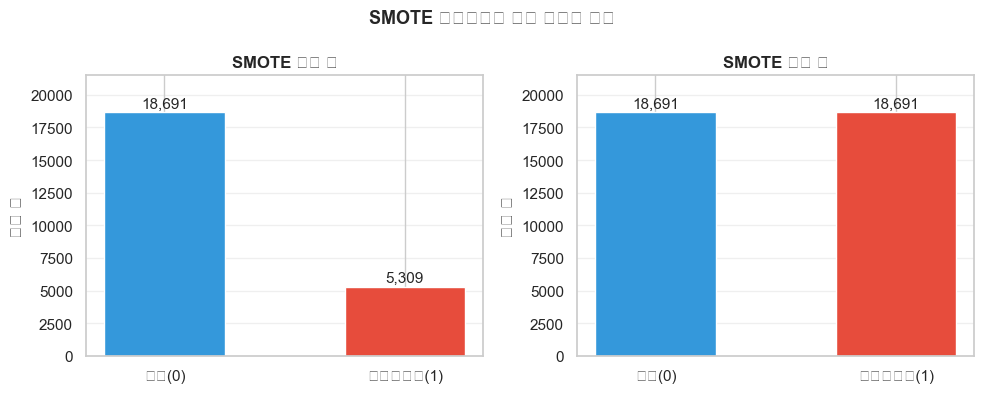

In [26]:
# ── Step 3: SMOTE 오버샘플링 ──
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('=' * 45)
print(' SMOTE 적용 결과')
print('=' * 45)
print(f' 적용 전 Train : {len(X_train):,}건')
print(f'   정상(0)       : {(y_train==0).sum():,}건')
print(f'   채무불이행(1)  : {(y_train==1).sum():,}건')
print()
print(f' 적용 후 Train : {len(X_train_sm):,}건')
print(f'   정상(0)       : {(y_train_sm==0).sum():,}건')
print(f'   채무불이행(1)  : {(y_train_sm==1).sum():,}건')
print(f' 채무불이행 비율 : {y_train_sm.mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, title) in zip(axes, [
    (y_train,    'SMOTE 적용 전'),
    (y_train_sm, 'SMOTE 적용 후'),
]):
    counts = y.value_counts().sort_index()
    bars = ax.bar(['정상(0)', '채무불이행(1)'], counts.values,
                  color=['#3498DB', '#E74C3C'], edgecolor='white', width=0.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{v:,}', ha='center', va='bottom', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('샘플 수')
    ax.set_ylim(0, counts.max() * 1.15)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('SMOTE 오버샘플링 전후 클래스 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4-2. 불균형 처리 방법 비교 (RFC 기준)

| 모델 | Precision | Recall | F1-Score | ROC-AUC |
|------|-----------|--------|----------|---------|
| 베이스라인 RFC | 0.64 | 0.36 | 0.46 | 0.7572 |
| RFC + class_weight='balanced' | 0.64 | 0.34 | 0.45 | 0.7583 |
| RFC + SMOTE | **0.51** | **0.48** | **0.49** | 0.7443 |

**결과 해석**
- `class_weight='balanced'` 는 RFC에서 효과 미미 (트리 앙상블 특성상 가중치 효과 제한적)
- **SMOTE** 적용 시 Recall 0.36 → 0.48 로 **+0.12** 개선 (채무불이행 탐지율 향상)
- Precision은 0.64 → 0.51로 하락 — Recall↑ Precision↓ 트레이드오프 관계
- **채무불이행 탐지(Recall)가 비즈니스 목적 → SMOTE 적용을 최종 전략으로 채택**


## 4-3. 3개 모델 학습 (SMOTE 적용 데이터)

- **Logistic Regression** — 베이스라인
- **Random Forest** — 트리 앙상블
- **XGBoost** — 부스팅

> SMOTE로 Train 데이터 균형화 완료 → `class_weight` / `scale_pos_weight` 별도 설정 불필요


In [27]:
# 4-3-1. Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

lr_pred       = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]
print('Logistic Regression 학습 완료 ✓')


Logistic Regression 학습 완료 ✓


In [28]:
# 4-3-2. Random Forest
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
print('Random Forest 학습 완료 ✓')


Random Forest 학습 완료 ✓


In [29]:
# 4-3-3. XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred       = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
print('XGBoost 학습 완료 ✓')


XGBoost 학습 완료 ✓


# 5. 모델 평가

- **Classification Report** — Accuracy, Precision, Recall, F1-Score
- **Confusion Matrix** — 실제 예측 오류 패턴 확인
- **ROC-AUC Curve** — 불균형 데이터에서 특히 중요


In [30]:
# 5-1. Classification Report — 3모델 비교
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

models_eval = {
    'Logistic Regression': (lr_pred,  lr_pred_proba),
    'Random Forest'      : (rf_pred,  rf_pred_proba),
    'XGBoost'            : (xgb_pred, xgb_pred_proba),
}

summary_rows = []
for name, (pred, proba) in models_eval.items():
    print(f"{'='*50}")
    print(f'  {name}')
    print(f"{'='*50}")
    print(classification_report(y_test, pred, target_names=['정상(0)', '채무불이행(1)']))
    summary_rows.append({
        '모델'     : name,
        'Accuracy' : accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall'   : recall_score(y_test, pred),
        'F1-Score' : f1_score(y_test, pred),
        'ROC-AUC'  : roc_auc_score(y_test, proba),
    })

summary_df = pd.DataFrame(summary_rows).set_index('모델')
print('\n=== 모델 성능 요약 (최고값 초록 하이라이트) ===')
display(summary_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))


  Logistic Regression
              precision    recall  f1-score   support

       정상(0)       0.86      0.75      0.80      4673
    채무불이행(1)       0.40      0.58      0.47      1327

    accuracy                           0.71      6000
   macro avg       0.63      0.67      0.64      6000
weighted avg       0.76      0.71      0.73      6000

  Random Forest
              precision    recall  f1-score   support

       정상(0)       0.87      0.84      0.86      4673
    채무불이행(1)       0.50      0.56      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

  XGBoost
              precision    recall  f1-score   support

       정상(0)       0.85      0.90      0.88      4673
    채무불이행(1)       0.56      0.45      0.50      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.68      0.69      6000
weighted avg       0.79   

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
모델,,,,,
Logistic Regression,0.7140,0.3996,0.5833,0.4743,0.7148
Random Forest,0.7802,0.5027,0.5599,0.5298,0.7701
XGBoost,0.8002,0.5595,0.4537,0.5010,0.7619


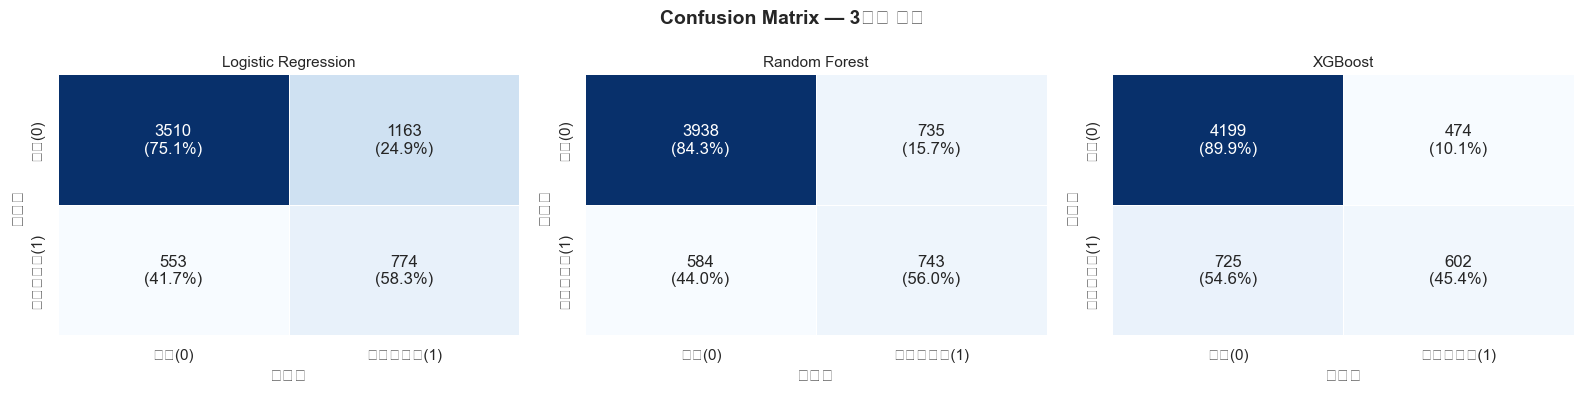

In [31]:
# 5-2. Confusion Matrix 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrix — 3모델 비교', fontsize=14, fontweight='bold')

for ax, (name, (pred, _)) in zip(axes, models_eval.items()):
    cm     = confusion_matrix(y_test, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array(
        [[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
         for row_v, row_p in zip(cm, cm_pct)]
    )
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['정상(0)', '채무불이행(1)'],
                yticklabels=['정상(0)', '채무불이행(1)'],
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')

plt.tight_layout()
plt.show()


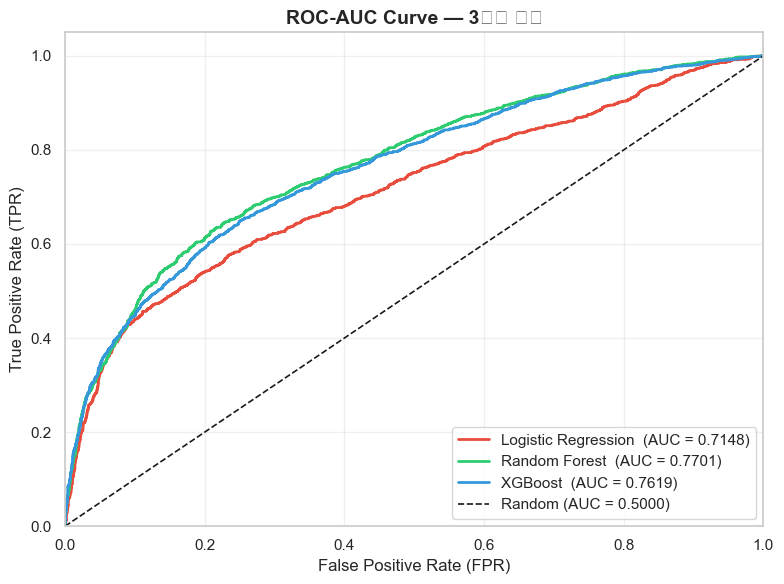

In [32]:
# 5-3. ROC-AUC Curve 시각화
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
colors = {'Logistic Regression': '#E74C3C', 'Random Forest': '#2ECC71', 'XGBoost': '#3498DB'}

for name, (_, proba) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc(fpr, tpr):.4f})',
             color=colors[name], lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-AUC Curve — 3모델 비교', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 6. 피처 중요도


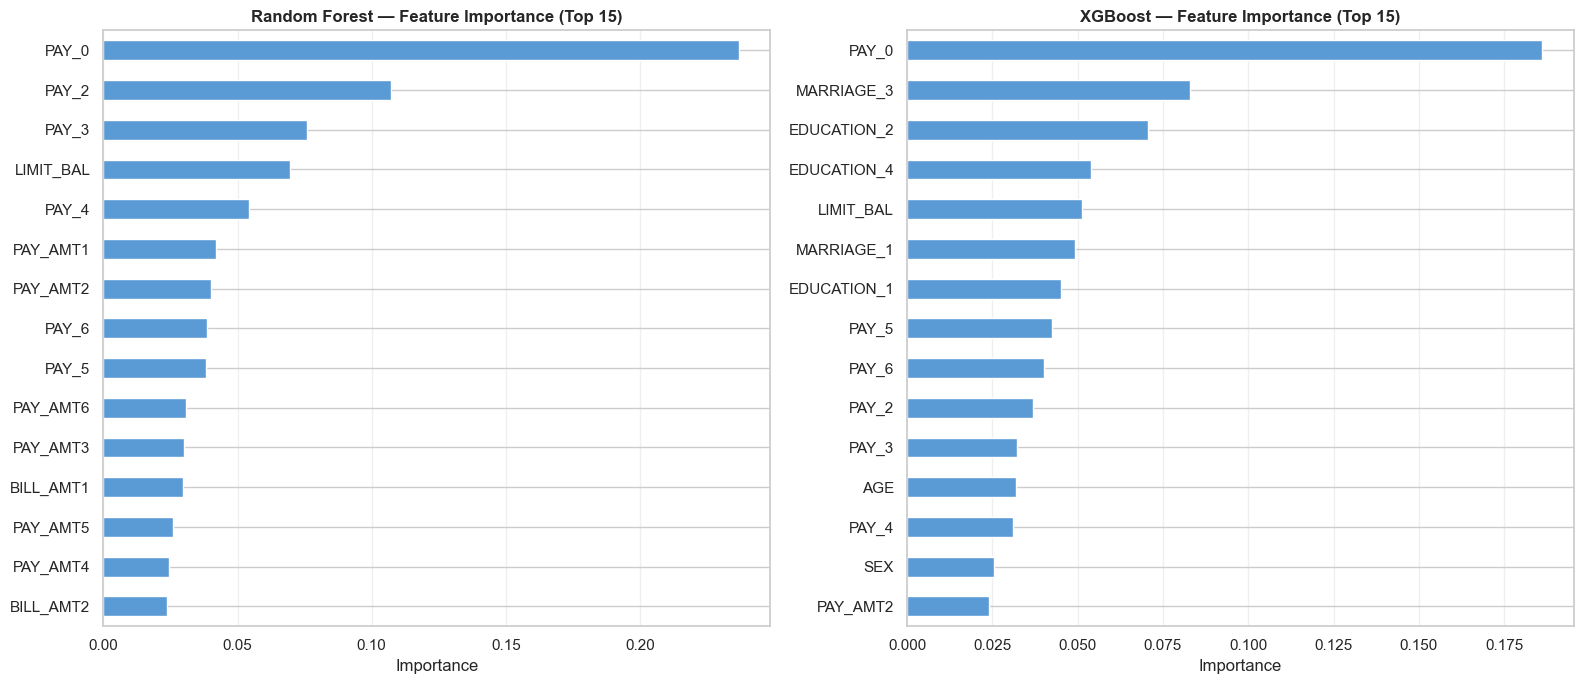

In [33]:
# 6. 피처 중요도 — RF / XGBoost 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (model, title) in zip(axes, [
    (rf_model,  'Random Forest'),
    (xgb_model, 'XGBoost'),
]):
    importances = pd.Series(model.feature_importances_, index=X_final.columns)
    top15 = importances.sort_values(ascending=True).tail(15)
    top15.plot(kind='barh', ax=ax, color='#5B9BD5', edgecolor='white')
    ax.set_title(f'{title} — Feature Importance (Top 15)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
